# Decision Tree Worksheet

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

## YOUR CODE HERE
data = pd.read_csv(url, names = names)

invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace = 0, value = np.nan, inplace = True)

data = data.dropna(axis = 0).reset_index(drop = True)

X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size = test_size, random_state = 0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = test_size, random_state = 0)

/tmp/ipykernel_663/2681766829.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace = 0, value = np.nan, inplace = True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [6]:
## YOUR CODE HERE
decision_tree = DecisionTreeClassifier(criterion = "entropy", max_depth = 20, min_samples_leaf = 3)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=3)

Print accuracy of training and validation data.

In [7]:
## YOUR CODE HERE
y_train_pred = decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred) * 100)

y_val_pred = decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val, y_val_pred) * 100)

Training Accuracy is  94.39999999999999
Validation Accuracy is  73.01587301587301


Make a model with a low max-depth and higher minimum sample leafs.

In [8]:
## YOUR CODE HERE
decision_tree2 = DecisionTreeClassifier(criterion = "entropy", max_depth = 5, min_samples_leaf = 15)
decision_tree2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=15)

Print accuracy of training and validation data.

In [9]:
## YOUR CODE HERE
y_train_pred2 = decision_tree2.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred2) * 100)

y_val_pred2 = decision_tree2.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val, y_val_pred2) * 100)

Training Accuracy is  80.80000000000001
Validation Accuracy is  80.95238095238095


Explain the accuracy results below.

The first decision tree overfitted the training data. The high depth cause the boundary to be over complex to fit the training data. Similarly the low minimum number of samples needed per leaf caused too many leaves to apply to random chance.

The second decision tree did not overfit the data, instead making the data apply to both equally (with validation slightly higher), increasing the validation accuracy.

## Metrics

Plot the ROC curve and print the AUC of the second model.

0.7945652173913045


Text(0, 0.5, 'TPR')

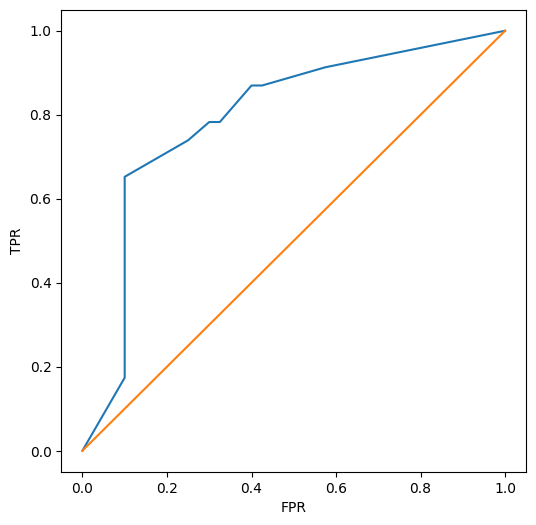

In [10]:
## YOUR CODE HERE
labels = [0,1]
y_val_prob = decision_tree2.predict_proba(X_val,labels)
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob[:,1])

roc_auc = metrics.auc(fpr, tpr)
print(roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])

plt.xlabel("FPR")
plt.ylabel("TPR")

Use graphviz to visualize your 2nd tree.

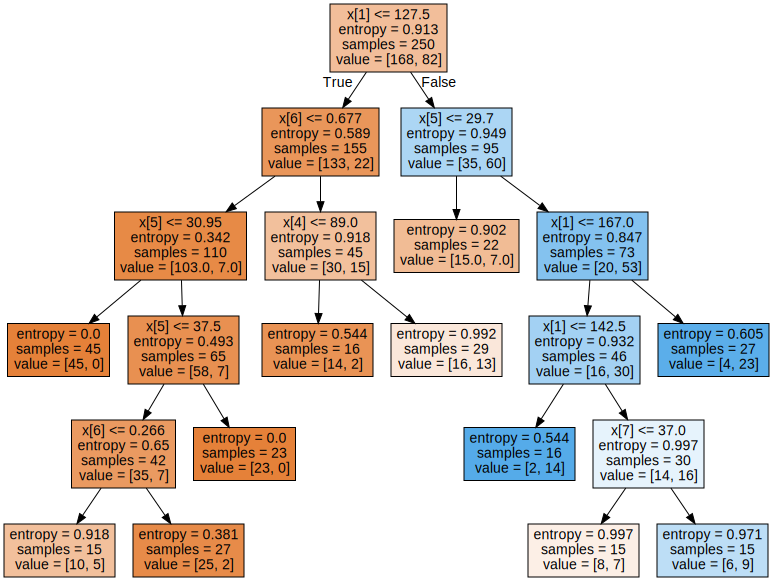

In [11]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(decision_tree2, out_file = None, filled = True)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

The plas feature in column 1

Question 2: What is the root feature? Does it make sense as the root feature?

X[1] with a threshold of <= 127.5. It makes sense because it separates the data the most out of all data points, because glucose level is very correlated to diabetes.

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

The training accuracy would be extremely high because each point gets its own special category. However, this is overfitting and would not apply to every data point, so the test accuracy would severly suffer.

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [12]:
## YOUR CODE HERE
decision_tree3 = DecisionTreeClassifier(criterion = "entropy", max_depth = 500, min_samples_leaf = 1)
decision_tree3.fit(X_train, y_train)

y_train_pred3 = decision_tree3.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred3) * 100)

y_val_pred3 = decision_tree3.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val, y_val_pred3) * 100)

Training Accuracy is  100.0
Validation Accuracy is  79.36507936507937


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [13]:
## YOUR CODE HERE
decision_tree4 = RandomForestClassifier()
decision_tree4.fit(X_train, y_train)

RandomForestClassifier()

Print accuracy of training and validation data.

In [14]:
## YOUR CODE HERE
y_train_pred4 = decision_tree4.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred4) * 100)

y_val_pred4 = decision_tree4.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val, y_val_pred4) * 100)

Training Accuracy is  100.0
Validation Accuracy is  79.36507936507937


How did the accuracy compare to the decision tree's accuracy?

(YOUR ANSWER HERE)

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [15]:
## YOUR CODE HERE
features = pd.Series(decision_tree4.feature_importances_, index = X_train.columns).sort_values(ascending=False)
features.head(3)

,0
plas,0.244791
test,0.157572
age,0.138507


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

Validation Accuracy: 58.730158730158735
Validation Accuracy: 73.01587301587301
Validation Accuracy: 77.77777777777779
Validation Accuracy: 74.60317460317461
Validation Accuracy: 79.36507936507937
Validation Accuracy: 73.01587301587301
Validation Accuracy: 77.77777777777779
Validation Accuracy: 77.77777777777779
Validation Accuracy: 77.77777777777779
Validation Accuracy: 80.95238095238095
Validation Accuracy: 79.36507936507937
Validation Accuracy: 80.95238095238095
Validation Accuracy: 76.19047619047619
Validation Accuracy: 84.12698412698413
Validation Accuracy: 82.53968253968253
Validation Accuracy: 77.77777777777779
Validation Accuracy: 79.36507936507937
Validation Accuracy: 79.36507936507937
Validation Accuracy: 79.36507936507937
Validation Accuracy: 77.77777777777779


Text(0, 0.5, 'Accuracy')

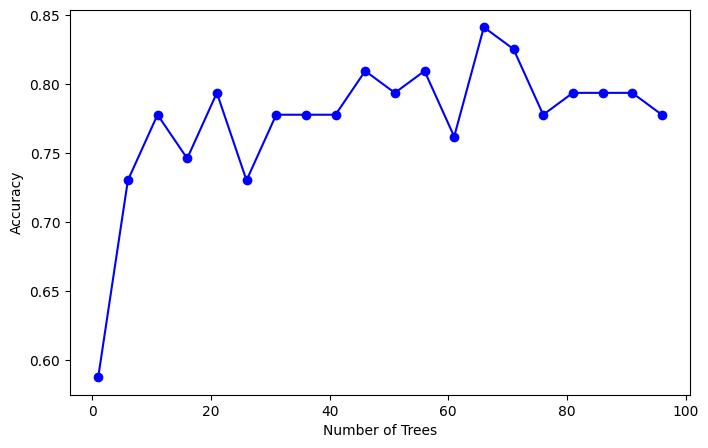

In [19]:
## YOUR CODE HERE

accuracies = []

for i in range(1, 101, 5):
  model = RandomForestClassifier(n_estimators=i)
  model.fit(X_train, y_train)

  y_val_pred = model.predict(X_val)
  acc = accuracy_score(y_val, y_val_pred)
  accuracies.append(acc)

  print(f"Validation Accuracy: {acc * 100}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101, 5), accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')


Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

In [ ]:
## YOUR CODE HERE
labels = [0,1]
y_val_prob = decision_tree4.predict_proba(X_val)
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob[:,1])

roc_auc = metrics.auc(fpr, tpr)
print(roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])

plt.xlabel("FPR")
plt.ylabel("TPR")